# 🔧 실습 2: LLM 파인튜닝 방법론 비교 (30분)

**목표**: Full Fine-Tuning, LoRA, QLoRA의 차이를 이해하고,
실제로 파라미터 수와 메모리를 비교하며 LoRA가 왜 효율적인지 체험합니다.

---

## 📚 왜 파인튜닝이 필요한가?

```
사전학습 모델 (GPT, LLaMA 등)     →  범용적이지만 특정 작업에 최적화 안 됨
    + 파인튜닝 (캐릭터 대화 데이터)  →  캐릭터 말투/성격을 학습한 모델
```

문제: 7B 모델을 통째로 학습하려면 GPU 메모리 60GB+ 필요 → 일반 GPU로는 불가능!

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
print("✅ 준비 완료")

✅ 준비 완료


## Part 1: Full Fine-Tuning vs LoRA 원리 (10분)

### Full Fine-Tuning
모든 파라미터를 학습 → 성능 최고, 메모리 최악

### LoRA (Low-Rank Adaptation)
핵심 아이디어: **가중치 변화량(ΔW)을 저랭크 행렬로 분해**

```
원래:  W' = W + ΔW           (ΔW: d×d 행렬 전체 학습)
LoRA:  W' = W + B × A        (A: d×r, B: r×d, r << d)
```

r=8이면 파라미터가 **수백 배** 줄어듭니다!

In [2]:
# ============================================================
# LoRA를 처음부터 구현
# ============================================================

class LoRALinear(nn.Module):
    """
    LoRA가 적용된 Linear 레이어
    
    원리: y = Wx + BAx
    - W: 원본 가중치 (고정, 학습 안 함)
    - B, A: 저랭크 행렬 (이것만 학습!)
    """
    
    def __init__(self, original_layer, rank=4, alpha=1.0):
        super().__init__()
        self.original = original_layer
        self.original.weight.requires_grad = False  # 원본 고정!
        
        in_features = original_layer.in_features
        out_features = original_layer.out_features
        
        # LoRA 행렬: A (down-projection) + B (up-projection)
        self.lora_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))
        
        self.scale = alpha / rank  # 스케일링 팩터
        
    def forward(self, x):
        # 원본 출력 + LoRA 출력
        original_output = self.original(x)
        lora_output = (x @ self.lora_A @ self.lora_B) * self.scale
        return original_output + lora_output


# 비교: 원본 vs LoRA
d_model = 4096  # 실제 LLM에서 흔한 차원 크기
rank = 8        # LoRA rank

original_layer = nn.Linear(d_model, d_model, bias=False)
lora_layer = LoRALinear(original_layer, rank=rank)

# 파라미터 수 비교
full_params = d_model * d_model
lora_params = d_model * rank + rank * d_model  # A + B

print(f"📊 파라미터 수 비교 (d_model={d_model}, rank={rank})")
print(f"="*50)
print(f"Full Fine-Tuning: {full_params:>12,}개  (W 전체)")
print(f"LoRA (rank={rank}):    {lora_params:>12,}개  (A + B)")
print(f"")
print(f"→ LoRA는 원본의 {lora_params/full_params*100:.2f}%만 학습!")
print(f"→ {full_params/lora_params:.0f}배 효율적!")

📊 파라미터 수 비교 (d_model=4096, rank=8)
Full Fine-Tuning:   16,777,216개  (W 전체)
LoRA (rank=8):          65,536개  (A + B)

→ LoRA는 원본의 0.39%만 학습!
→ 256배 효율적!


In [3]:
# ============================================================
# LoRA가 실제로 작동하는지 확인
# ============================================================

# 테스트 입력
x = torch.randn(1, d_model)

# LoRA 적용 전 (B가 0이므로 원본과 동일)
with torch.no_grad():
    out_original = original_layer(x)
    out_lora_before = lora_layer(x)
    diff_before = (out_original - out_lora_before).abs().mean().item()

print(f"LoRA 학습 전 차이: {diff_before:.6f}")
print(f"  → B가 0으로 초기화되어 있어 원본과 동일! (LoRA의 핵심 설계)")

# LoRA 학습 시뮬레이션 (B에 값을 넣어봄)
with torch.no_grad():
    lora_layer.lora_B.data = torch.randn_like(lora_layer.lora_B) * 0.1
    out_lora_after = lora_layer(x)
    diff_after = (out_original - out_lora_after).abs().mean().item()

print(f"\nLoRA 학습 후 차이: {diff_after:.6f}")
print(f"  → A, B가 학습되면서 출력이 변화! 원본 W는 그대로 보존됨")

LoRA 학습 전 차이: 0.000000
  → B가 0으로 초기화되어 있어 원본과 동일! (LoRA의 핵심 설계)

LoRA 학습 후 차이: 0.019507
  → A, B가 학습되면서 출력이 변화! 원본 W는 그대로 보존됨


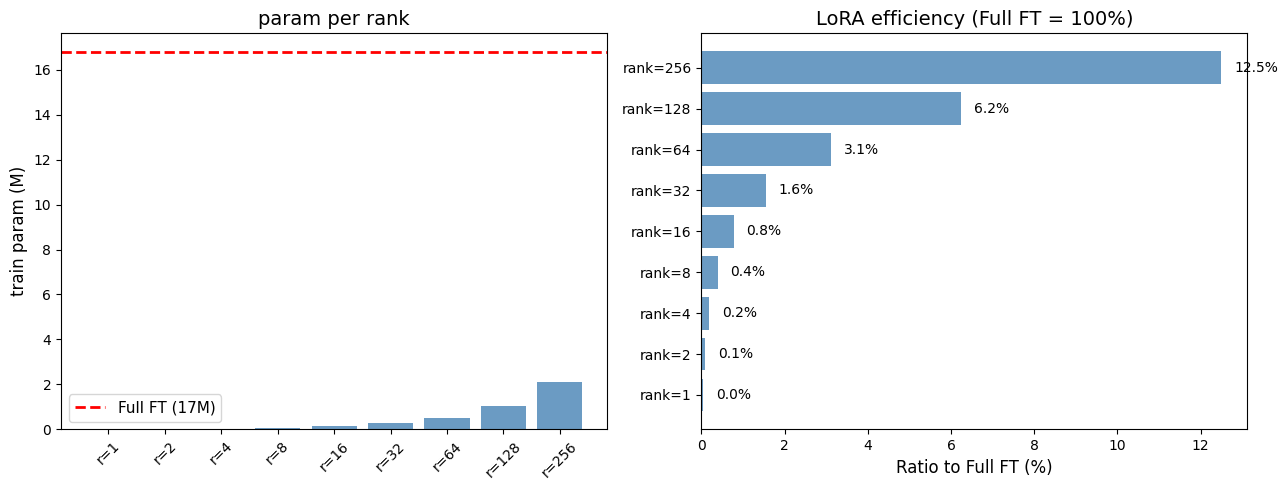

💡 실전 가이드:
  rank=8~16  → 일반적인 태스크 (번역, 요약, QA)
  rank=32~64 → 캐릭터 챗봇처럼 말투/스타일 학습이 중요한 경우
  rank=128+  → Full FT에 근접한 성능이 필요할 때


In [5]:
# ============================================================
# Rank에 따른 표현력 vs 효율성 트레이드오프
# ============================================================

d = 4096
ranks = [1, 2, 4, 8, 16, 32, 64, 128, 256]

full = d * d
lora_sizes = [d * r * 2 for r in ranks]
ratios = [s / full * 100 for s in lora_sizes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 파라미터 수
ax1.bar(range(len(ranks)), [s/1e6 for s in lora_sizes], color='steelblue', alpha=0.8)
ax1.axhline(y=full/1e6, color='red', linestyle='--', linewidth=2, label=f'Full FT ({full/1e6:.0f}M)')
ax1.set_xticks(range(len(ranks)))
ax1.set_xticklabels([f'r={r}' for r in ranks], rotation=45)
ax1.set_ylabel('train param (M)', fontsize=12)
ax1.set_title('param per rank', fontsize=14)
ax1.legend(fontsize=11)

# 오른쪽: 비율
colors = ['green' if r <= 1 else 'steelblue' if r <= 5 else 'orange' for r in ratios]
ax2.barh(range(len(ranks)), ratios, color='steelblue', alpha=0.8)
ax2.set_yticks(range(len(ranks)))
ax2.set_yticklabels([f'rank={r}' for r in ranks])
ax2.set_xlabel('Ratio to Full FT (%)', fontsize=12)
ax2.set_title('LoRA efficiency (Full FT = 100%)', fontsize=14)
for i, r in enumerate(ratios):
    ax2.text(r + 0.3, i, f'{r:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("💡 실전 가이드:")
print("  rank=8~16  → 일반적인 태스크 (번역, 요약, QA)")
print("  rank=32~64 → 캐릭터 챗봇처럼 말투/스타일 학습이 중요한 경우")
print("  rank=128+  → Full FT에 근접한 성능이 필요할 때")

## Part 2: 학습 방법론 전체 비교 (10분)

| 방법 | 원리 | 메모리 | 성능 |
|------|------|--------|------|
| **Full FT** | 모든 파라미터 학습 | 최대 (60GB+) | 최고 |
| **LoRA** | 저랭크 행렬만 학습 | 중간 (16GB~) | 좋음 |
| **QLoRA** | 4bit 양자화 + LoRA | 최소 (8GB~) | 약간 저하 |
| **Prompt Tuning** | 프롬프트 벡터만 학습 | 최소 | 제한적 |
| **Adapter** | 작은 모듈 삽입 | 중간 | 좋음 |

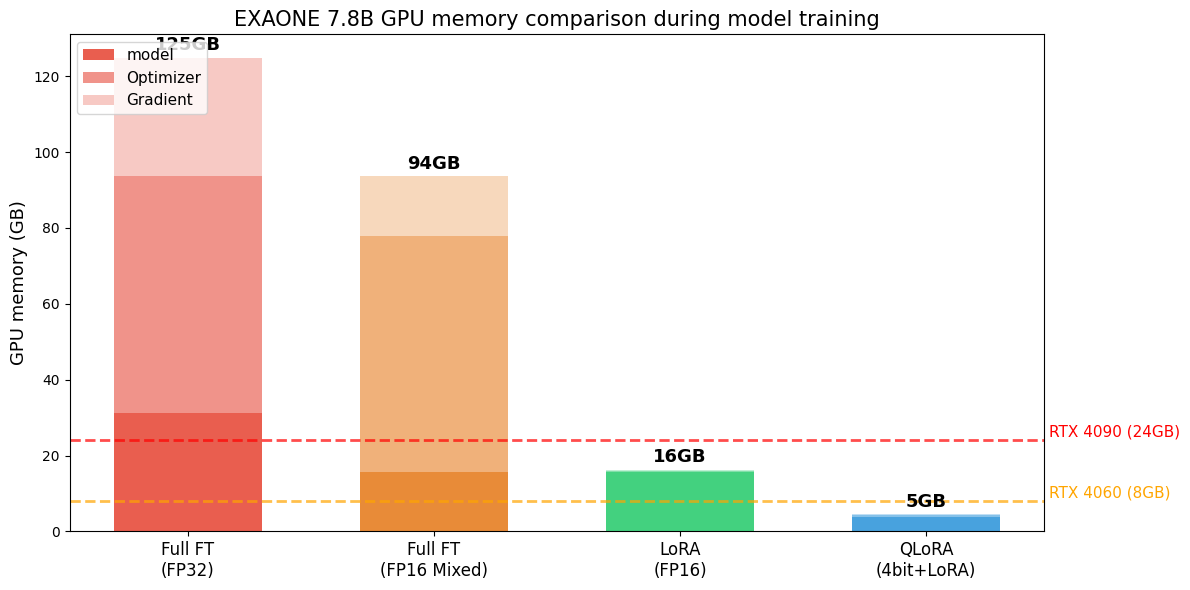

💡 결론:
  Full FT → A100 80GB 같은 고가 GPU 필요
  LoRA    → RTX 3090/4090 (24GB)로 가능
  QLoRA   → RTX 4060 (8GB)로도 가능!


In [10]:
# ============================================================
# 7B 모델 기준 각 방법론의 메모리 비교
# ============================================================

model_size_B = 7.8  # EXAONE 7.8B 기준
param_bytes_fp16 = model_size_B * 1e9 * 2  # FP16 = 2 bytes
param_bytes_fp32 = model_size_B * 1e9 * 4  # FP32 = 4 bytes
param_bytes_4bit = model_size_B * 1e9 * 0.5  # 4bit = 0.5 bytes

methods = {
    "Full FT\n(FP32)": {
        "model": param_bytes_fp32 / 1e9,
        "optimizer": param_bytes_fp32 / 1e9 * 2,  # Adam: 2배
        "gradients": param_bytes_fp32 / 1e9,
        "color": "#e74c3c"
    },
    "Full FT\n(FP16 Mixed)": {
        "model": param_bytes_fp16 / 1e9,
        "optimizer": param_bytes_fp32 / 1e9 * 2,
        "gradients": param_bytes_fp16 / 1e9,
        "color": "#e67e22"
    },
    "LoRA\n(FP16)": {
        "model": param_bytes_fp16 / 1e9,
        "optimizer": param_bytes_fp16 / 1e9 * 0.02,  # 2% 파라미터만
        "gradients": param_bytes_fp16 / 1e9 * 0.02,
        "color": "#2ecc71"
    },
    "QLoRA\n(4bit+LoRA)": {
        "model": param_bytes_4bit / 1e9,
        "optimizer": param_bytes_fp16 / 1e9 * 0.02,
        "gradients": param_bytes_fp16 / 1e9 * 0.02,
        "color": "#3498db"
    },
}

fig, ax = plt.subplots(figsize=(12, 6))

x_pos = range(len(methods))
width = 0.6

for i, (name, data) in enumerate(methods.items()):
    total = data["model"] + data["optimizer"] + data["gradients"]
    
    # 누적 바
    b1 = ax.bar(i, data["model"], width, color=data["color"], alpha=0.9, label="model" if i==0 else None)
    b2 = ax.bar(i, data["optimizer"], width, bottom=data["model"], color=data["color"], alpha=0.6, label="Optimizer" if i==0 else None)
    b3 = ax.bar(i, data["gradients"], width, bottom=data["model"]+data["optimizer"], color=data["color"], alpha=0.3, label="Gradient" if i==0 else None)
    
    ax.text(i, total + 1, f'{total:.0f}GB', ha='center', va='bottom', fontsize=13, fontweight='bold')

# 24GB 라인
ax.axhline(y=24, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.text(len(methods)-0.5, 25, 'RTX 4090 (24GB)', color='red', fontsize=11)

ax.axhline(y=8, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax.text(len(methods)-0.5, 9, 'RTX 4060 (8GB)', color='orange', fontsize=11)

ax.set_xticks(x_pos)
ax.set_xticklabels(methods.keys(), fontsize=12)
ax.set_ylabel('GPU memory (GB)', fontsize=13)
ax.set_title(f'EXAONE {model_size_B}B GPU memory comparison during model training', fontsize=15)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print("💡 결론:")
print("  Full FT → A100 80GB 같은 고가 GPU 필요")
print("  LoRA    → RTX 3090/4090 (24GB)로 가능")
print("  QLoRA   → RTX 4060 (8GB)로도 가능!")

## Part 3: LoRA 적용 대상 — 어디에 붙이나? (10분)

Transformer의 모든 레이어에 LoRA를 붙일 수 있지만,
보통 **Attention의 Q, K, V, O projection**에 적용합니다.

In [8]:
# ============================================================
# 실제 모델에서 LoRA 적용 시뮬레이션
# ============================================================

class SimpleTransformerBlock(nn.Module):
    """단순화된 Transformer 블록"""
    def __init__(self, d_model=512):
        super().__init__()
        # Attention projections
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.o_proj = nn.Linear(d_model, d_model, bias=False)
        
        # MLP (Feed-Forward)
        self.gate_proj = nn.Linear(d_model, d_model * 4, bias=False)
        self.up_proj = nn.Linear(d_model, d_model * 4, bias=False)
        self.down_proj = nn.Linear(d_model * 4, d_model, bias=False)


def apply_lora(model, target_modules, rank=8):
    """모델에 LoRA를 적용하는 함수"""
    lora_params = 0
    frozen_params = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            is_target = any(t in name for t in target_modules)
            d_in, d_out = module.in_features, module.out_features
            original = d_in * d_out
            
            if is_target:
                lora = d_in * rank + rank * d_out
                lora_params += lora
                status = f"✅ LoRA (rank={rank}): +{lora:,} 학습 파라미터"
            else:
                status = f"❄️ 고정 (frozen)"
            
            frozen_params += original
            print(f"  {name:12s} [{d_in}×{d_out}] = {original:>10,} params → {status}")
    
    return frozen_params, lora_params


# 시뮬레이션 실행
block = SimpleTransformerBlock(d_model=512)

print("📊 Transformer 블록에 LoRA 적용 (rank=8)")
print("="*70)

# 전략 1: Q, V만 (가장 일반적)
print("\n🎯 전략 1: Q, V projection만 (가장 일반적)")
print("-"*70)
frozen1, lora1 = apply_lora(block, ["q_proj", "v_proj"], rank=8)
print(f"  → 학습 비율: {lora1/(frozen1)*100:.2f}%")

# 전략 2: 전체 Attention
print("\n🎯 전략 2: Q, K, V, O 전부")
print("-"*70)
frozen2, lora2 = apply_lora(block, ["q_proj", "k_proj", "v_proj", "o_proj"], rank=8)
print(f"  → 학습 비율: {lora2/(frozen2)*100:.2f}%")

# 전략 3: Attention + MLP (캐릭터 챗봇 추천)
print("\n🎯 전략 3: Attention + MLP 전체 (캐릭터 챗봇 추천)")
print("-"*70)
frozen3, lora3 = apply_lora(block, ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], rank=8)
print(f"  → 학습 비율: {lora3/(frozen3)*100:.2f}%")

📊 Transformer 블록에 LoRA 적용 (rank=8)

🎯 전략 1: Q, V projection만 (가장 일반적)
----------------------------------------------------------------------
  q_proj       [512×512] =    262,144 params → ✅ LoRA (rank=8): +8,192 학습 파라미터
  k_proj       [512×512] =    262,144 params → ❄️ 고정 (frozen)
  v_proj       [512×512] =    262,144 params → ✅ LoRA (rank=8): +8,192 학습 파라미터
  o_proj       [512×512] =    262,144 params → ❄️ 고정 (frozen)
  gate_proj    [512×2048] =  1,048,576 params → ❄️ 고정 (frozen)
  up_proj      [512×2048] =  1,048,576 params → ❄️ 고정 (frozen)
  down_proj    [2048×512] =  1,048,576 params → ❄️ 고정 (frozen)
  → 학습 비율: 0.39%

🎯 전략 2: Q, K, V, O 전부
----------------------------------------------------------------------
  q_proj       [512×512] =    262,144 params → ✅ LoRA (rank=8): +8,192 학습 파라미터
  k_proj       [512×512] =    262,144 params → ✅ LoRA (rank=8): +8,192 학습 파라미터
  v_proj       [512×512] =    262,144 params → ✅ LoRA (rank=8): +8,192 학습 파라미터
  o_proj       [512×512] =    262,144 pa

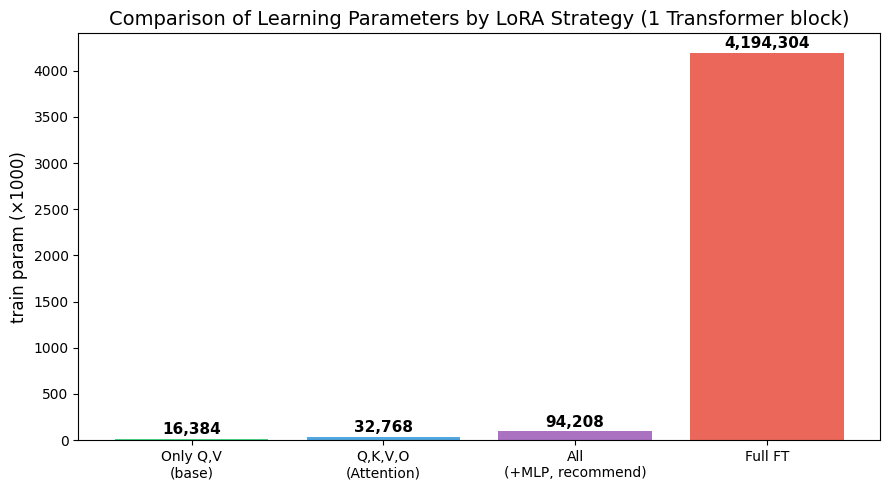

💡 캐릭터 챗봇 파인튜닝 팁:
  1. rank=32, 전체 Attention+MLP에 LoRA 적용
  2. 학습률: 2e-4 (LoRA는 일반 FT보다 높게)
  3. 에폭: 3~5 (과적합 주의)
  4. 데이터: 캐릭터별 최소 500~1000 대화 턴


In [13]:
# ============================================================
# 전략별 비교 시각화
# ============================================================

strategies = {
    'Only Q,V\n(base)': lora1,
    'Q,K,V,O\n(Attention)': lora2,
    'All\n(+MLP, recommend)': lora3,
    'Full FT': frozen3,
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(strategies.keys(), [v/1000 for v in strategies.values()], color=colors, alpha=0.85)

for bar, val in zip(bars, strategies.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('train param (×1000)', fontsize=12)
ax.set_title('Comparison of Learning Parameters by LoRA Strategy (1 Transformer block)', fontsize=14)
plt.tight_layout()
plt.show()

print("💡 캐릭터 챗봇 파인튜닝 팁:")
print("  1. rank=32, 전체 Attention+MLP에 LoRA 적용")
print("  2. 학습률: 2e-4 (LoRA는 일반 FT보다 높게)")
print("  3. 에폭: 3~5 (과적합 주의)")
print("  4. 데이터: 캐릭터별 최소 500~1000 대화 턴")

## ✅ 실습 2 요약

| 방법 | 학습 대상 | GPU 메모리 (7B 기준) | 장점 | 단점 |
|------|-----------|---------------------|------|------|
| **Full FT** | 전체 파라미터 | ~60GB | 최고 성능 | GPU 비용 |
| **LoRA** | 저랭크 행렬 (0.1~2%) | ~18GB | 효율적 + 좋은 성능 | rank 튜닝 필요 |
| **QLoRA** | 4bit 모델 + LoRA | ~6GB | 소형 GPU 가능 | 약간의 품질 저하 |

### 핵심 하이퍼파라미터
- **rank (r)**: 높을수록 표현력 ↑, 메모리 ↑ (캐릭터 챗봇: 32 추천)
- **alpha (α)**: 보통 rank의 2배 (α=64 when r=32)
- **target_modules**: 어떤 레이어에 LoRA를 적용할지

**다음 실습**: 실제 EXAONE 모델로 AI 캐릭터 챗봇 체험! →